In [2]:
from collections import defaultdict
from datetime import datetime, timezone
import io

import pandas as pd
import matplotlib.pyplot as plt
import chess.pgn

from utils.chesscom_repository import ChessComRepository
from utils.opening_repository import OpeningRepository

In [3]:
USERNAME = "bassisw"

MAX_GAMES = 200      # X: total games to pull
TOP_K = 10           # top K openings
SINCE_YEAR = 2025    # optional
SINCE_MONTH = 1      # optional

In [4]:
chesscom_repo = ChessComRepository(USERNAME)
opening_repo = OpeningRepository("openings_dataset/all.tsv")

print(f"Loaded {len(opening_repo)} opening positions")

Loaded 3709 opening positions


In [5]:
def get_result_for_user(game_data, username: str) -> str:
    username = username.lower()

    white_username = game_data["white"]["username"].lower()
    black_username = game_data["black"]["username"].lower()

    white_result = game_data["white"]["result"]
    black_result = game_data["black"]["result"]

    if white_username == username:
        user_color = "white"
        user_result = white_result
    elif black_username == username:
        user_color = "black"
        user_result = black_result
    else:
        raise ValueError("Username not found in game")

    if user_result == "win":
        result = "win"
    elif user_result in {"checkmated", "resigned", "timeout", "abandoned", "lose"}:
        result = "loss"
    else:
        result = "draw"

    return user_color, result


def parse_pgn_game(pgn_text: str):
    return chess.pgn.read_game(io.StringIO(pgn_text))


def detect_opening_from_game_pgn(pgn_text: str):
    game = parse_pgn_game(pgn_text)
    if game is None:
        return None
    return opening_repo.detect_from_pgn_game(game)

In [6]:
games = []

for game_data in chesscom_repo.iter_all_games(
    since_year=SINCE_YEAR,
    since_month=SINCE_MONTH,
):
    if "pgn" not in game_data:
        continue

    games.append(game_data)

    if len(games) >= MAX_GAMES:
        break

print(f"Pulled {len(games)} games")

Pulled 200 games


In [7]:
records = []

for game_data in games:
    try:
        user_color, result = get_result_for_user(game_data, USERNAME)
        opening = detect_opening_from_game_pgn(game_data["pgn"])

        if opening is None:
            opening_name = "Unknown"
            eco = None
        else:
            opening_name = opening.name
            eco = opening.eco

        records.append({
            "url": game_data.get("url"),
            "time_class": game_data.get("time_class"),
            "user_color": user_color,
            "result": result,
            "opening_name": opening_name,
            "eco": eco,
        })

    except Exception as exc:
        print(f"Skipped game because of error: {exc}")

df = pd.DataFrame(records)

df.head()

,url,time_class,user_color,result,opening_name,eco
0,https://www.chess.com/game/live/130193958939,blitz,white,loss,"English Opening: Anglo-Indian Defense, Hedgeho...",A17
1,https://www.chess.com/game/live/130632620901,bullet,black,win,Portuguese Opening,C20
2,https://www.chess.com/game/live/130632682387,bullet,black,draw,Creepy Crawly Formation: Classical Defense,A00
3,https://www.chess.com/game/live/136244392598,blitz,black,win,Van't Kruijs Opening,A00
4,https://www.chess.com/game/live/138872446461,rapid,black,draw,Scotch Game,C44


In [15]:
def compute_opening_stats(
    df: pd.DataFrame,
    time_class: str,
    color: str,
):
    subset = df[
        (df["time_class"] == time_class)
        &
        (df["user_color"] == color)
    ]

    stats = (
        subset
        .groupby(["eco", "opening_name"])
        .agg(
            games=("result", "count"),
            wins=("result", lambda x: (x == "win").sum()),
            losses=("result", lambda x: (x == "loss").sum()),
            draws=("result", lambda x: (x == "draw").sum()),
        )
        .reset_index()
    )

    stats["winrate"] = (
        stats["wins"]
        / stats["games"]
        * 100
    )

    return stats.sort_values(
        "games",
        ascending=False,
    )


white_openings = compute_opening_stats(df, time_class="rapid", color="white").head(TOP_K)
black_openings = compute_opening_stats(df, time_class="rapid", color="black").head(TOP_K)

white_openings

,eco,opening_name,games,wins,losses,draws,winrate
13,D00,Queen's Pawn Game: Accelerated London System,22,9,12,1,40.909091
17,D02,"Queen's Pawn Game: London System, with e6",7,4,3,0,57.142857
7,A45,Indian Defense: Accelerated London System,5,3,1,1,60.000000
16,D02,Queen's Pawn Game: London System,3,3,0,0,100.000000
3,A40,Horwitz Defense,3,1,2,0,33.333333
5,A40,Queen's Pawn Game: Modern Defense,2,1,1,0,50.000000
14,D00,"Queen's Pawn Game: Accelerated London System, ...",2,1,1,0,50.000000
11,B13,Caro-Kann Defense: Exchange Variation,1,1,0,0,100.000000
15,D02,Queen's Pawn Game: Chigorin Variation,1,1,0,0,100.000000
12,C21,Danish Gambit,1,1,0,0,100.000000


In [16]:
black_openings

,eco,opening_name,games,wins,losses,draws,winrate
8,B00,Pirc Defense,21,14,7,0,66.666667
15,B08,Pirc Defense: Classical Variation,8,6,2,0,75.000000
4,A45,Indian Defense: Accelerated London System,3,0,3,0,0.000000
0,A00,Van't Kruijs Opening,2,0,2,0,0.000000
23,E20,Nimzo-Indian Defense,2,2,0,0,100.000000
17,C40,Latvian Gambit,2,0,2,0,0.000000
10,B00,Rat Defense: Harmonist,2,1,1,0,50.000000
12,B07,Pirc Defense,2,1,0,1,50.000000
3,A45,Indian Defense,2,0,2,0,0.000000
7,B00,Lion Defense: Lion's Jaw,1,0,1,0,0.000000


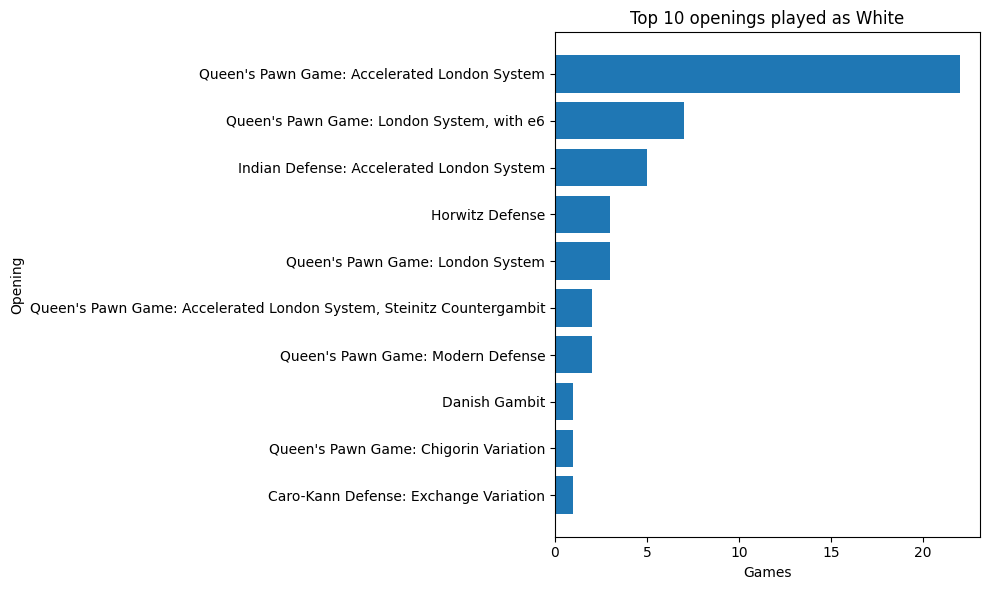

In [17]:
def plot_opening_frequency(stats_df: pd.DataFrame, title: str):
    plot_df = stats_df.sort_values("games", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["opening_name"], plot_df["games"])
    plt.xlabel("Games")
    plt.ylabel("Opening")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_opening_frequency(white_openings, f"Top {TOP_K} openings played as White")

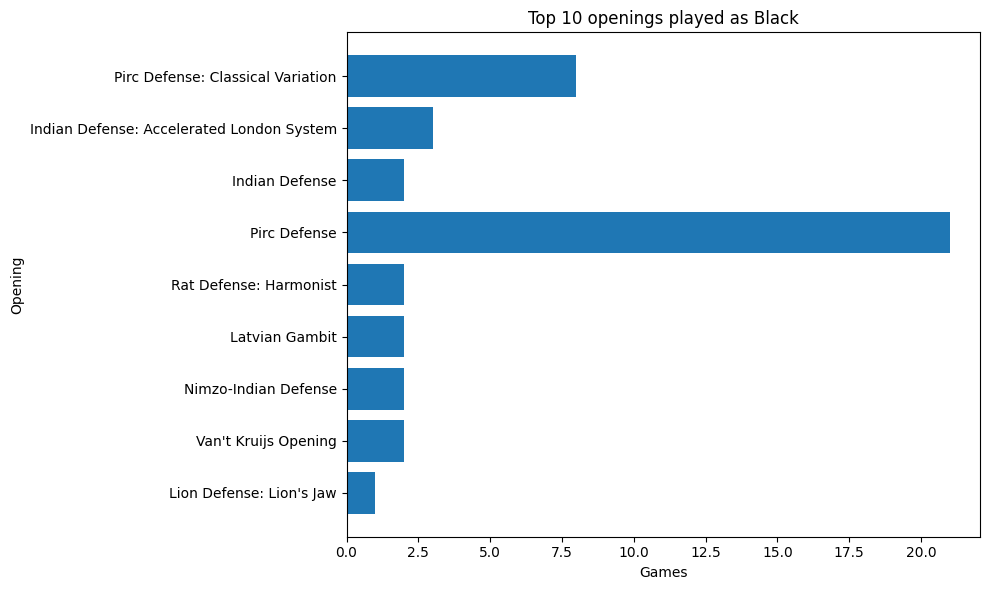

In [18]:
plot_opening_frequency(black_openings, f"Top {TOP_K} openings played as Black")

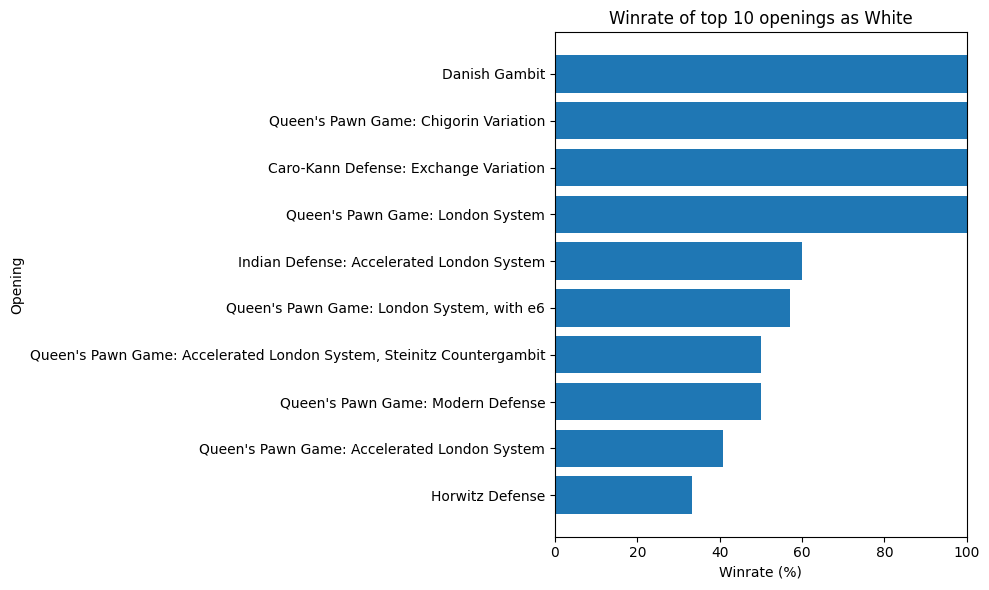

In [19]:
def plot_opening_winrate(stats_df: pd.DataFrame, title: str):
    plot_df = stats_df.sort_values("winrate", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["opening_name"], plot_df["winrate"])
    plt.xlabel("Winrate (%)")
    plt.ylabel("Opening")
    plt.title(title)
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()


plot_opening_winrate(white_openings, f"Winrate of top {TOP_K} openings as White")

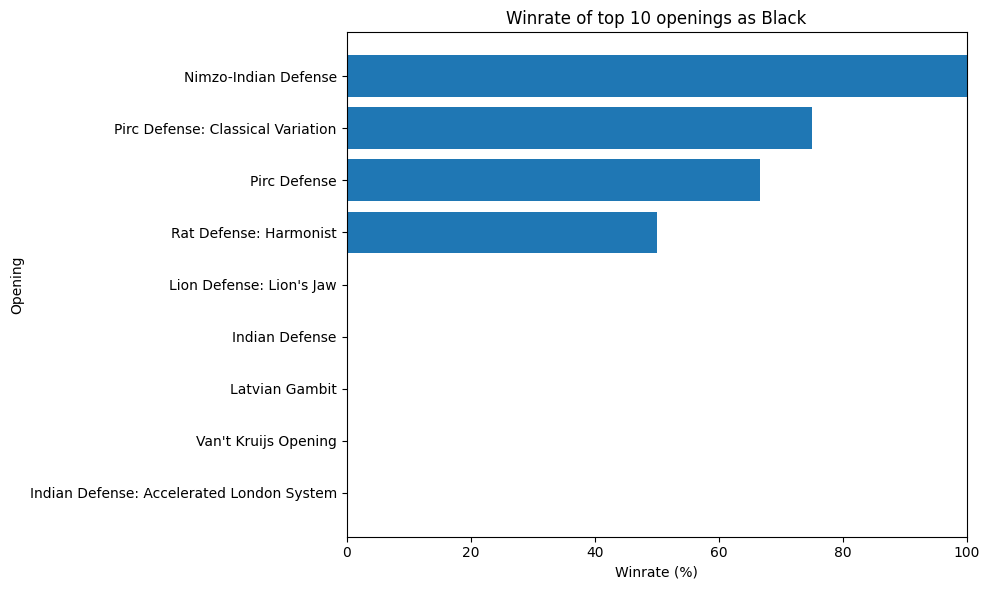

In [20]:
plot_opening_winrate(black_openings, f"Winrate of top {TOP_K} openings as Black")

In [21]:
summary = pd.concat(
    [
        white_openings.assign(color="white"),
        black_openings.assign(color="black"),
    ],
    ignore_index=True,
)

summary = summary[
    ["color", "eco", "opening_name", "games", "wins", "draws", "losses", "winrate"]
]

summary.sort_values(["color", "games"], ascending=[True, False])

,color,eco,opening_name,games,wins,draws,losses,winrate
10,black,B00,Pirc Defense,21,14,0,7,66.666667
11,black,B08,Pirc Defense: Classical Variation,8,6,0,2,75.000000
12,black,A45,Indian Defense: Accelerated London System,3,0,0,3,0.000000
13,black,A00,Van't Kruijs Opening,2,0,0,2,0.000000
14,black,E20,Nimzo-Indian Defense,2,2,0,0,100.000000
15,black,C40,Latvian Gambit,2,0,0,2,0.000000
16,black,B00,Rat Defense: Harmonist,2,1,0,1,50.000000
17,black,B07,Pirc Defense,2,1,1,0,50.000000
18,black,A45,Indian Defense,2,0,0,2,0.000000
19,black,B00,Lion Defense: Lion's Jaw,1,0,0,1,0.000000
